# Trabajo Semanal Nº2: Algoritmo para calcular la DFT

## Contenidos
1. Generador de señales (referencia a TS1)
2. Ejecución de DFT para todas las señales
3. Comparación con FFT
4. DFT de una señal aleatoria

## 1. Generador de señales

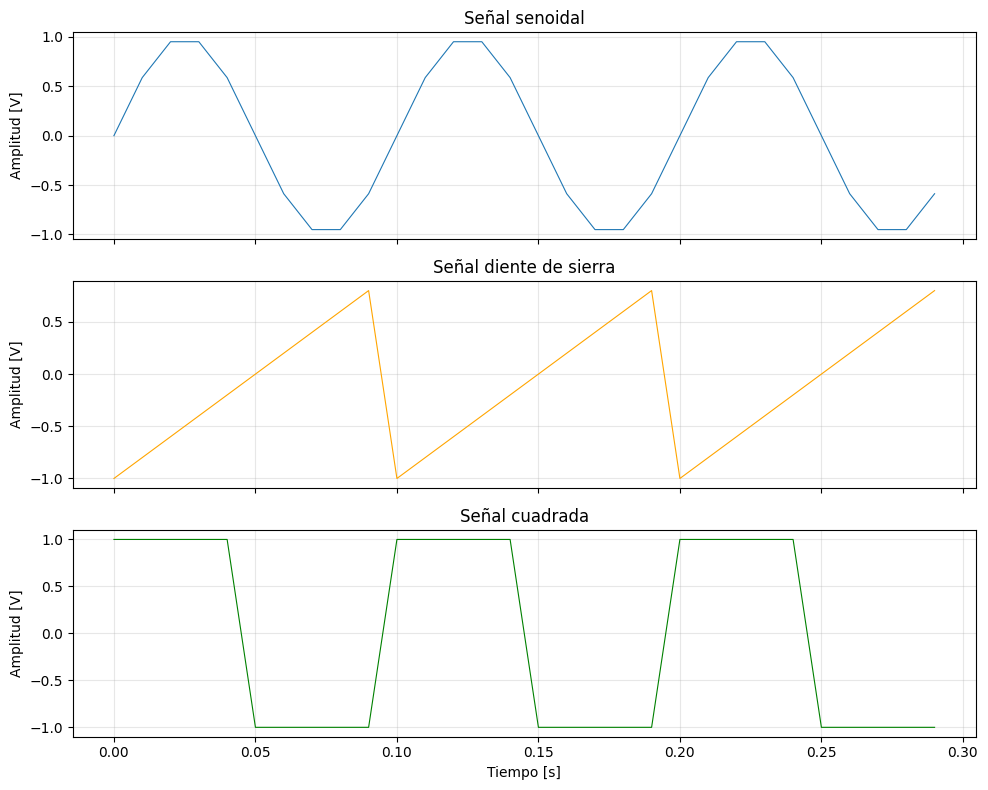

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Vector columna de tiempo
    tt = (np.arange(nn)/fs).reshape(-1,1)

    # Señal senoidal
    xx = vmax*np.sin(2*np.pi*ff*tt + ph) + dc    

    return tt, xx

def mi_funcion_sawtooth(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Vector columna de tiempo
    tt = (np.arange(nn)/fs).reshape(-1,1)

    # Señal diente de sierra
    xx = vmax*signal.sawtooth(2*np.pi*ff*tt + ph) + dc    

    return tt, xx

def mi_funcion_square(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Vector columna de tiempo
    tt = (np.arange(nn)/fs).reshape(-1,1)

    # Señal cuadrada
    xx = vmax*signal.square(2*np.pi*ff*tt + ph) + dc    

    return tt, xx

# Generar señales
tt, xx_sine     = mi_funcion_sen(1, 0, 10, 0, 30, 100)
_,  xx_sawtooth = mi_funcion_sawtooth(1, 0, 10, 0, 30, 100)
_,  xx_square   = mi_funcion_square(1, 0, 10, 0, 30, 100)

# Metadatos de cada señal
signals = [
    (xx_sine,     "Senoidal",         "steelblue"),
    (xx_sawtooth, "Diente de sierra", "orange"),
    (xx_square,   "Cuadrada",         "green"),
]

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(tt, xx_sine, linewidth=0.8)
axs[0].set_ylabel("Amplitud [V]")
axs[0].set_title("Señal senoidal")
axs[0].grid(True, alpha=0.3)

axs[1].plot(tt, xx_sawtooth, linewidth=0.8, color="orange")
axs[1].set_ylabel("Amplitud [V]")
axs[1].set_title("Señal diente de sierra")
axs[1].grid(True, alpha=0.3)

axs[2].plot(tt, xx_square, linewidth=0.8, color="green")
axs[2].set_ylabel("Amplitud [V]")
axs[2].set_title("Señal cuadrada")
axs[2].set_xlabel("Tiempo [s]")
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Implementación DFT + Gráficos

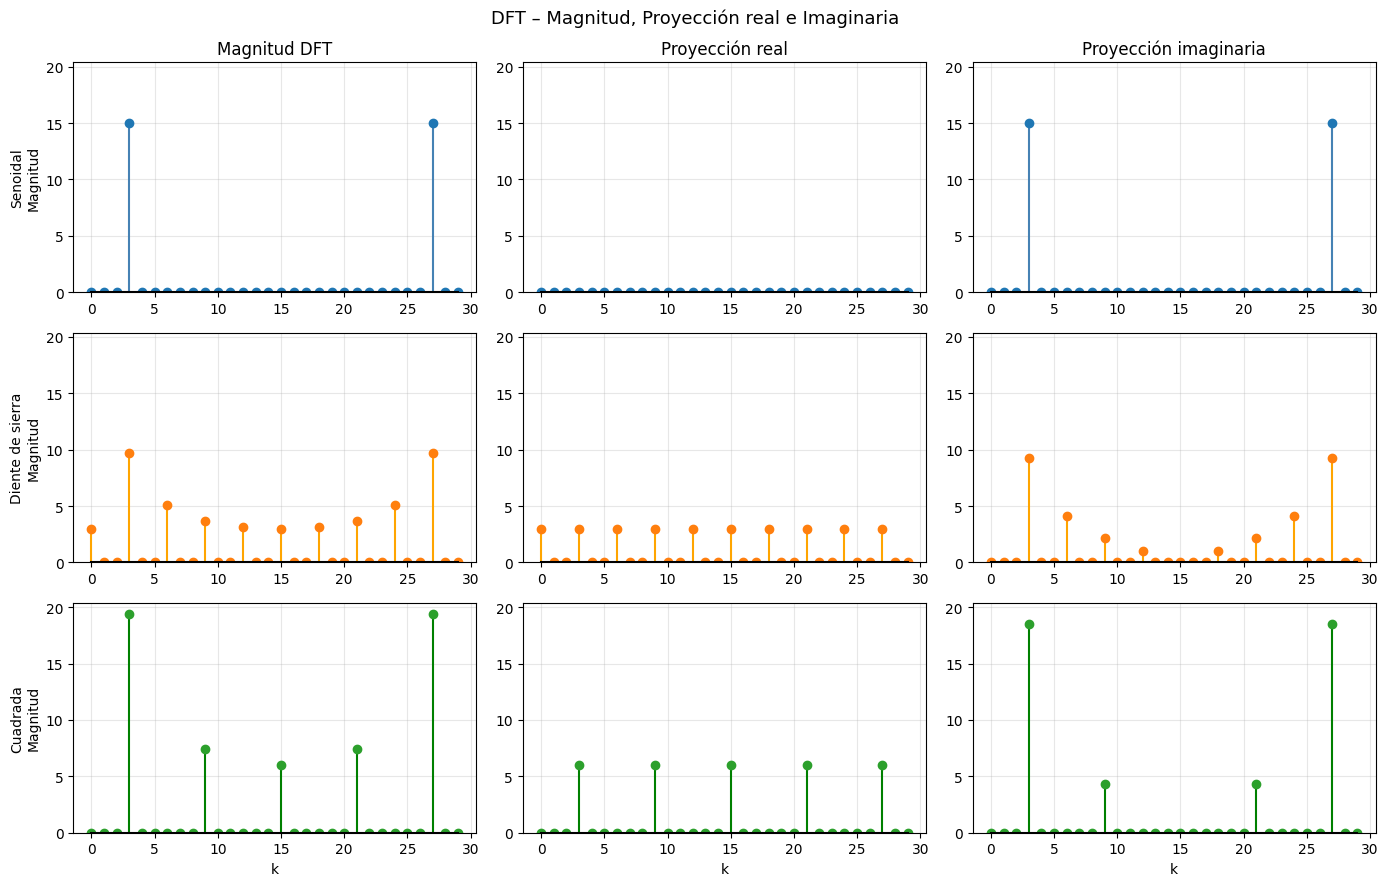

In [ ]:
# xx: señal a analizar, una matriz (Nx1) de números reales.
# XX: DFT de xx, una matriz (Nx1) de números complejos.
def dft(xx):
  N = xx.shape[0] # Cantidad de filas

  n = np.arange(N).reshape((1, N)) # Vector de indices de tiempo (n), Vector fila (1xN)
  k = np.arange(N).reshape((N, 1)) # Vector de indices para frecuencia (k), Vector columna (Nx1)

  theta = 2 * np.pi * k * n / N
  W = np.cos(theta) - 1j * np.sin(theta) # Matriz N x N de Twiddle Factors

  XX = np.dot(W, xx) # Producto escalar entre matrices
  return XX

def dft_real(x_c):
    N = x_c.shape[0]

    n = np.arange(N).reshape((1, N))
    k = np.arange(N).reshape((N, 1))

    theta = 2 * np.pi * k * n / N
    W = np.cos(theta)

    XX = np.dot(W, x_c)
    return XX

def dft_imag(x_c):
    N = x_c.shape[0]

    n = np.arange(N).reshape((1, N))
    k = np.arange(N).reshape((N, 1))

    theta = 2 * np.pi * k * n / N
    W = -1j * np.sin(theta)

    XX = np.dot(W, x_c)
    return XX

# DFTs
dfts = []
for sig, _, _ in signals:
    XX      = dft(sig)
    XX_real = dft_real(sig)
    XX_imag = dft_imag(sig)
    dfts.append((XX, XX_real, XX_imag))

# Máximo global para escala uniforme
y_max = max(
    max(np.abs(XX).max(), np.abs(XX_real).max(), np.abs(XX_imag).max())
    for XX, XX_real, XX_imag in dfts
)

# Mosaico DFT 3x3
fig2, axs2 = plt.subplots(3, 3, figsize=(14, 9))
col_titles = ["Magnitud DFT", "Proyección real", "Proyección imaginaria"]

for c, title in enumerate(col_titles):
    axs2[0, c].set_title(title)

for row, ((sig, label, color), (XX, XX_real, XX_imag)) in enumerate(zip(signals, dfts)):
    N_sig  = sig.shape[0]
    k_axis = np.arange(N_sig)

    axs2[row, 0].stem(k_axis, np.abs(XX),      linefmt=color, markerfmt=f"C{row}o", basefmt="k-")
    axs2[row, 1].stem(k_axis, np.abs(XX_real), linefmt=color, markerfmt=f"C{row}o", basefmt="k-")
    axs2[row, 2].stem(k_axis, np.abs(XX_imag), linefmt=color, markerfmt=f"C{row}o", basefmt="k-")

    axs2[row, 0].set_ylabel(f"{label}\nMagnitud")
    for c in range(3):
        axs2[row, c].set_ylim(0, y_max * 1.05)
        axs2[row, c].grid(True, alpha=0.3)
        if row == 2:
            axs2[row, c].set_xlabel("k")

fig2.suptitle("DFT – Magnitud, Proyección real e Imaginaria", fontsize=13)
plt.tight_layout()
plt.show()


## 3a. DFT vs FFT (Comparativa temporal)

In [50]:
import time

ffts = []
for sig, _, _ in signals:
    XX_fft = np.fft.fft(sig.flatten())
    ffts.append(XX_fft)

tiempos = []
for sig, label, _ in signals:
    # Tiempo DFT propia
    t0 = time.perf_counter()
    for _ in range(10):
        dft(sig)
    t_dft = (time.perf_counter() - t0) / 10

    # Tiempo FFT numpy
    t0 = time.perf_counter()
    for _ in range(10):
        np.fft.fft(sig.flatten())
    t_fft = (time.perf_counter() - t0) / 10

    tiempos.append((label, t_dft, t_fft))
    print(f"{label:20s}  DFT: {t_dft*1e6:.2f} µs   FFT: {t_fft*1e6:.2f} µs   Mejora: {t_dft/t_fft:.1f}x")


Senoidal              DFT: 53.04 µs   FFT: 6.43 µs   Mejora: 8.2x
Diente de sierra      DFT: 27.30 µs   FFT: 5.61 µs   Mejora: 4.9x
Cuadrada              DFT: 22.08 µs   FFT: 3.21 µs   Mejora: 6.9x


## 3b. DFT vs FFT (Gráficos)

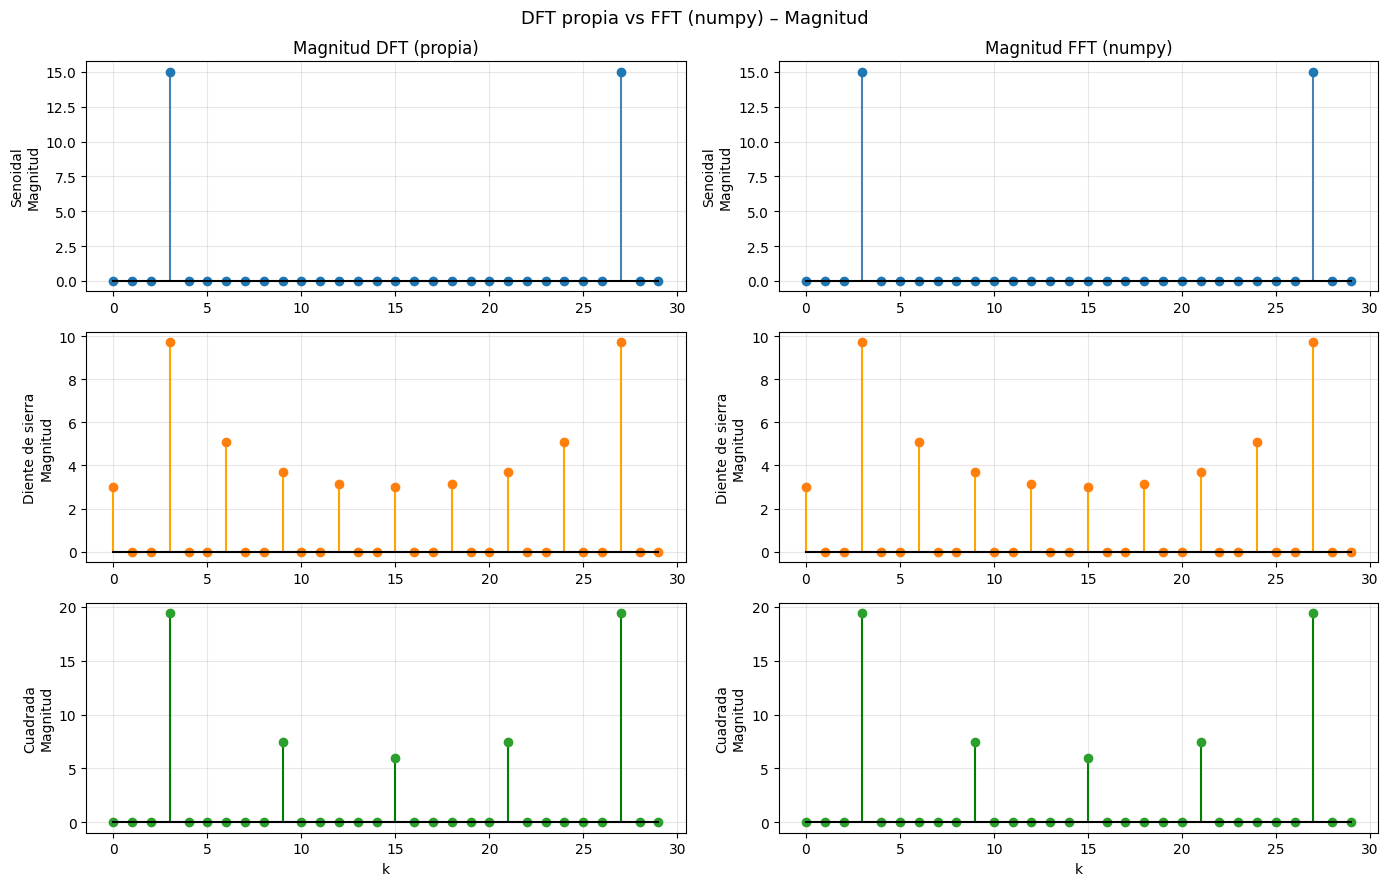

In [51]:
fig3, axs3 = plt.subplots(3, 2, figsize=(14, 9))
col_titles_cmp = ["Magnitud DFT (propia)", "Magnitud FFT (numpy)"]

for c, title in enumerate(col_titles_cmp):
    axs3[0, c].set_title(title)

for row, ((sig, label, color), (XX, _, __), XX_fft) in enumerate(zip(signals, dfts, ffts)):
    N_sig  = sig.shape[0]
    k_axis = np.arange(N_sig)

    axs3[row, 0].stem(k_axis, np.abs(XX.flatten()), linefmt=color, markerfmt=f"C{row}o", basefmt="k-")
    axs3[row, 1].stem(k_axis, np.abs(XX_fft),       linefmt=color, markerfmt=f"C{row}o", basefmt="k-")

    for c in range(2):
        axs3[row, c].set_ylabel(f"{label}\nMagnitud")
        axs3[row, c].grid(True, alpha=0.3)
        if row == 2:
            axs3[row, c].set_xlabel("k")

fig3.suptitle("DFT propia vs FFT (numpy) – Magnitud", fontsize=13)
plt.tight_layout()
plt.show()


## 4. DFT de una señal aleatoria 

Varianza de la señal generada: 4.0627  (objetivo: 4)


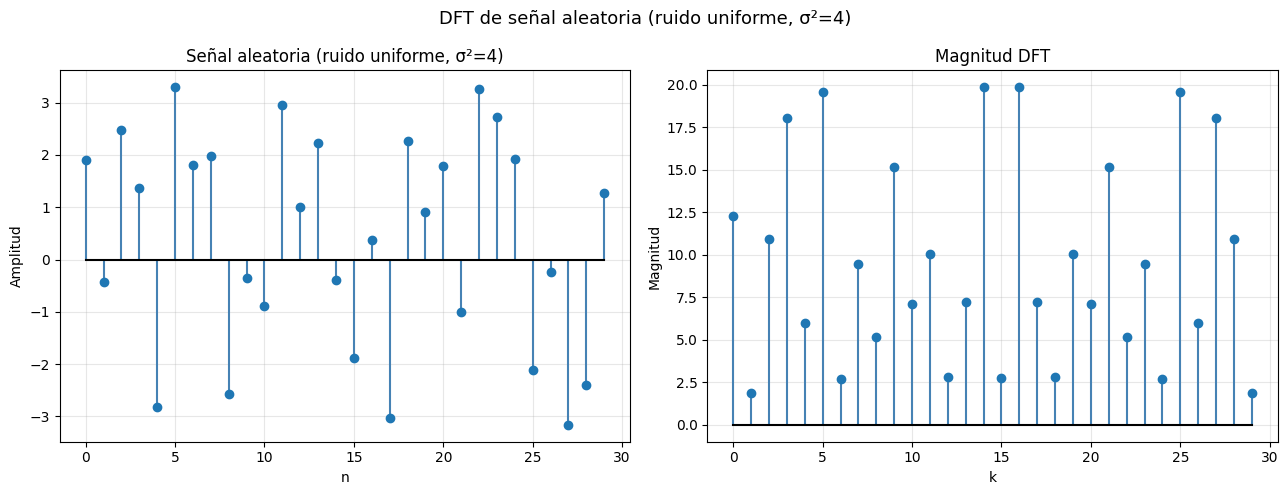

In [52]:
N_rand = 30
rng = np.random.default_rng(seed=42)
amplitude = 2 * np.sqrt(3)  # mitad del intervalo
xx_rand = rng.uniform(-amplitude, amplitude, N_rand).reshape(-1, 1)

print(f"Varianza de la señal generada: {np.var(xx_rand):.4f}  (objetivo: 4)")

# DFT
XX_rand = dft(xx_rand)
k_rand  = np.arange(N_rand)

fig4, axs4 = plt.subplots(1, 2, figsize=(13, 5))

# Señal en el tiempo
axs4[0].stem(k_rand, xx_rand.flatten(), linefmt="steelblue", markerfmt="C0o", basefmt="k-")
axs4[0].set_title("Señal aleatoria (ruido uniforme, σ²=4)")
axs4[0].set_xlabel("n")
axs4[0].set_ylabel("Amplitud")
axs4[0].grid(True, alpha=0.3)

# Magnitud DFT
axs4[1].stem(k_rand, np.abs(XX_rand.flatten()), linefmt="steelblue", markerfmt="C0o", basefmt="k-")
axs4[1].set_title("Magnitud DFT")
axs4[1].set_xlabel("k")
axs4[1].set_ylabel("Magnitud")
axs4[1].grid(True, alpha=0.3)

fig4.suptitle("DFT de señal aleatoria (ruido uniforme, σ²=4)", fontsize=13)
plt.tight_layout()
plt.show()
